# Three-axicon feasibility calculator — Candidate #1 constraints at D = 9.5 mm

Geometric (meridional-ray) calculator for the four Candidate-#1 requirements
(`Sr_Clock_Beam_Requirements`): **range > 1 m**, **central lobe > 300 µm over the
whole range**, **fits within the ½″ mirror going in**, **far ½″ mirror sits in the
void going out**. Companion to `three_axicon_d9p5_2026_07_25` (QDHT, wave-optics):
this notebook answers *which constraint binds and why* in closed form; that one
answers *what the intensity actually looks like*.

**Headline identity (2026-07-25 feasibility check)**: the rays that end the Bessel
range are the same rays that open the void behind it, at the same cone angle θ.
The core requirement caps θ, so the void opens no faster than

$$\Delta_{min} \;=\; \frac{R_{mirror}}{\theta_{cap}} \;=\; \frac{\pi\, R_{mirror}\, d_{core}}{2.405\,\lambda}
\;\approx\; 3.6\,\mathrm{m}\ @\ 698\,\mathrm{nm}$$

independent of every sweep parameter (verified against a 200 k random-config
exact-Snell sweep — min standoff found 3.565 m = this floor to 3 decimals).
Everything below lets you push on the knobs and watch the report card.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import j0

MM, UM, MRAD = 1e-3, 1e-6, 1e-3
J0_ZERO = 2.40483                                   # first zero of J0
X_HALF = brentq(lambda x: j0(x)**2 - 0.5, 0.5, 2.0) # J0^2 half-max (FWHM def)

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "three_axicon_feasibility_calculator_2026_07_25"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

## Knobs

Everything is set in the next cell; re-run from there down after any change.
`SIGNS` convention: each axicon changes a ray's slope by −`sign`·β·sgn(h)
(**+1 = deflect toward the axis**). Note the matched relay is `[+1, +1, +1]`,
not `[+1, −1, +1]`: the rays cross the axis between axicons 1 and 2, so
"toward the axis" applied to the crossed rays *is* recollimation.

`RAY_BAND` picks which encircled-power band of the input Gaussian defines the
geometric range endpoints; `(0, 0.865)` means h ∈ (0, w] (86.5 % of the power)
and reproduces the simple range = w/θ quote.

In [2]:
# --- requirements (Sr_Clock_Beam_Requirements) --------------------------------
LAM         = 698e-9      # 698e-9 production Sr clock | 650e-9 diode test
D_CORE      = 300 * UM    # required central-lobe diameter over the whole range
CORE_DEF    = "zero"      # "zero" = zero-to-zero | "fwhm" (halves the theta cap)
L_RANGE     = 1.0         # required Bessel range (m)
R_MIRROR    = 12.7 * MM / 2   # 1/2-inch cavity mirror radius
VOID_MARGIN = 1.0         # 1.0 = mirror edge just clear; 2.0 = the ">>" reading

# --- input beam ----------------------------------------------------------------
D_IN     = 9.50 * MM      # measured 1/e^2 diameter (jul24 telescope, +-0.10)
W_IN     = D_IN / 2
RAY_BAND = (0.0, 0.865)   # encircled-power band tracing the range endpoints

# --- design under test: the three axicons --------------------------------------
N_GLASS   = 1.4585                        # as in the QDHT notebooks
                                          # (UVFS Sellmeier: 1.4565 @650, 1.4553 @698)
ALPHA_DEG = np.array([1.0, 1.0, 0.20])    # base angles (deg), axicons 1..3
SIGNS     = np.array([+1, +1, +1])        # +1 toward axis (see markdown above)
L12       = 1007 * MM                     # annulus outer radius ~ beta1*L12 ~ 8 mm
L23       = 50 * MM

## Constraint algebra

Core diameter ↔ cone angle: $d = X\,\lambda/(2\pi\theta)$ with $X = 2\cdot2.405$
(zero-to-zero) or $2\cdot1.126$ (FWHM). So $d \ge d_{req}$ caps the final cone
angle at $\theta_{cap} = X\lambda/(2\pi d_{req})$. Everything downstream of the
third axicon then follows: range $= \Delta h_{rays}/\theta$, post-range void opens
at exactly $\theta$, and the standoff to clear the far mirror is
$\Delta = m\,R_{mirror}/\theta \ge m\,R_{mirror}/\theta_{cap}$.

In [3]:
def core_x(core_def=None):
    return 2 * (J0_ZERO if (core_def or CORE_DEF) == "zero" else X_HALF)

def core_diam(theta, lam=None, core_def=None):
    lam = LAM if lam is None else lam
    return core_x(core_def) * lam / (2 * np.pi * theta)

def theta_cap(lam=None, d_core=None, core_def=None):
    lam = LAM if lam is None else lam
    d_core = D_CORE if d_core is None else d_core
    return core_x(core_def) * lam / (2 * np.pi * d_core)

def encircled_h(P):
    """Radius enclosing fraction P of the input Gaussian power."""
    return W_IN * np.sqrt(0.5 * np.log(1 / (1 - max(P, 1e-12))))

print(f"{'lam':>7} {'core def':>9} | {'theta_cap':>10} {'range@cap':>10} "
      f"{'standoff x1':>12} {'standoff x2':>12}")
for lam in (650e-9, 698e-9):
    for cdef in ("zero", "fwhm"):
        th = theta_cap(lam=lam, core_def=cdef)
        rng = (encircled_h(RAY_BAND[1]) - encircled_h(RAY_BAND[0])) / th
        print(f"{lam*1e9:5.0f}nm {cdef:>9} | {th/MRAD:8.3f} mr {rng:8.2f} m "
              f"{R_MIRROR/th:10.2f} m {2*R_MIRROR/th:10.2f} m")
th_now = theta_cap()
print(f"\ncurrent requirement -> theta <= {th_now/MRAD:.3f} mrad, "
      f"far-mirror standoff >= {VOID_MARGIN*R_MIRROR/th_now:.2f} m "
      f"(margin x{VOID_MARGIN:.0f})")

    lam  core def |  theta_cap  range@cap  standoff x1  standoff x2
  650nm      zero |    1.659 mr     2.87 m       3.83 m       7.66 m
  650nm      fwhm |    0.777 mr     6.12 m       8.17 m      16.35 m
  698nm      zero |    1.781 mr     2.67 m       3.57 m       7.13 m
  698nm      fwhm |    0.834 mr     5.70 m       7.61 m      15.22 m

current requirement -> theta <= 1.781 mrad, far-mirror standoff >= 3.57 m (margin x1)


## Ray model and report card

Exact-Snell deflection at each thin ideal axicon; the four constraints are then
checked on the traced fan. The void check cannot pass or fail on its own — it
returns **the standoff the chamber must provide**, which is the one number still
pending from the apparatus side.

In [4]:
def deflect(alpha_rad, n=None):
    """Exact axicon deflection magnitude (flat side first, near-normal incidence)."""
    n = N_GLASS if n is None else n
    return np.arcsin(np.clip(n * np.sin(alpha_rad), -1, 1)) - alpha_rad

def trace(h0):
    """Meridional rays through the three thin axicons -> (h, u) at axicon-3 plane."""
    h = np.atleast_1d(h0).astype(float)
    u = np.zeros_like(h)
    for L, b, s in zip((0.0, L12, L23), deflect(np.deg2rad(ALPHA_DEG)), SIGNS):
        h = h + u * L
        u = u - s * b * np.where(h == 0, 1.0, np.sign(h))
    return h, u

def analyze(n_rays=2001, verbose=True):
    h0 = np.linspace(max(encircled_h(RAY_BAND[0]), 1e-4 * W_IN),
                     encircled_h(RAY_BAND[1]), n_rays)
    h, u = trace(h0)
    u = np.where(h < 0, -u, u)                # fold to h >= 0
    h = np.abs(h)
    out = dict(h=h, u=u, rho_in=h.min(), rho_out=h.max())
    if not np.all(u < 0):
        if verbose:
            print("FAIL: some traced rays never cross the axis -> no complete "
                  "Bessel region (check SIGNS / angles)")
        return out | dict(ok=False)
    zc, th = -h / u, -u                       # crossing position, local cone angle
    order = np.argsort(zc)
    zc, th = zc[order], th[order]
    ok = core_diam(th) >= D_CORE
    best, i, win = 0.0, 0, (np.nan, np.nan)   # longest contiguous window meeting core
    while i < len(zc):
        if ok[i]:
            j = i
            while j + 1 < len(zc) and ok[j + 1]:
                j += 1
            if zc[j] - zc[i] > best:
                best, win = zc[j] - zc[i], (zc[i], zc[j])
            i = j + 1
        else:
            i += 1
    z_start, z_end, th_end = zc[0], zc[-1], th[-1]
    outer_at_start = np.max(h + u * z_start)  # beam outer radius at range start
    # how far below range start the 1/2-inch opening can sit (outer radius <= R_MIRROR)
    zg = np.linspace(0, z_start, 400)
    outer = np.max(np.abs(h[:, None] + u[:, None] * zg), axis=0)
    fit_from = zg[outer <= R_MIRROR][0] if np.any(outer <= R_MIRROR) else np.nan
    standoff = VOID_MARGIN * R_MIRROR / th_end
    out |= dict(ok=True, zc=zc, th=th, z_start=z_start, z_end=z_end,
                th_end=th_end, window=win, window_len=best,
                outer_at_start=outer_at_start, fit_from=fit_from,
                standoff=standoff)
    if verbose:
        d_end = core_diam(th_end)
        Y, N = "PASS", "FAIL"
        print(f"annulus at axicon 3: rho = {out['rho_in']/MM:.2f} - "
              f"{out['rho_out']/MM:.2f} mm (width {(out['rho_out']-out['rho_in'])/MM:.2f} mm)")
        print(f"Bessel region: z = {z_start:.2f} - {z_end:.2f} m after axicon 3; "
              f"cone angle at end {th_end/MRAD:.3f} mrad -> core {d_end/UM:.0f} um")
        print(f"[1] range > {L_RANGE:.0f} m with core >= {D_CORE/UM:.0f} um:  "
              f"{Y if best >= L_RANGE else N}  ({best:.2f} m)")
        print(f"[2] core >= {D_CORE/UM:.0f} um over that window:   "
              f"{Y if best > 0 else N}  (theta_cap {theta_cap()/MRAD:.3f} mrad)")
        print(f"[3] fits 1/2-inch going in:            "
              f"{Y if outer_at_start <= R_MIRROR else N}  "
              f"({outer_at_start/MM:.2f} mm at range start; opening ok from "
              f"{z_start - fit_from:.2f} m below range start)")
        print(f"[4] far mirror in void (margin x{VOID_MARGIN:.0f}):    NEEDS "
              f"standoff >= {standoff:.2f} m beyond end of range")
    return out

res = analyze()

annulus at axicon 3: rho = 3.31 - 8.06 mm (width 4.75 mm)
Bessel region: z = 2.07 - 5.04 m after axicon 3; cone angle at end 1.600 mrad -> core 334 um
[1] range > 1 m with core >= 300 um:  PASS  (2.97 m)
[2] core >= 300 um over that window:   PASS  (theta_cap 1.781 mrad)
[3] fits 1/2-inch going in:            PASS  (4.75 mm at range start; opening ok from 0.99 m below range start)
[4] far mirror in void (margin x1):    NEEDS standoff >= 3.97 m beyond end of range


saved images/three_axicon_feasibility_calculator_2026_07_25/ray_diagram_current_design.png


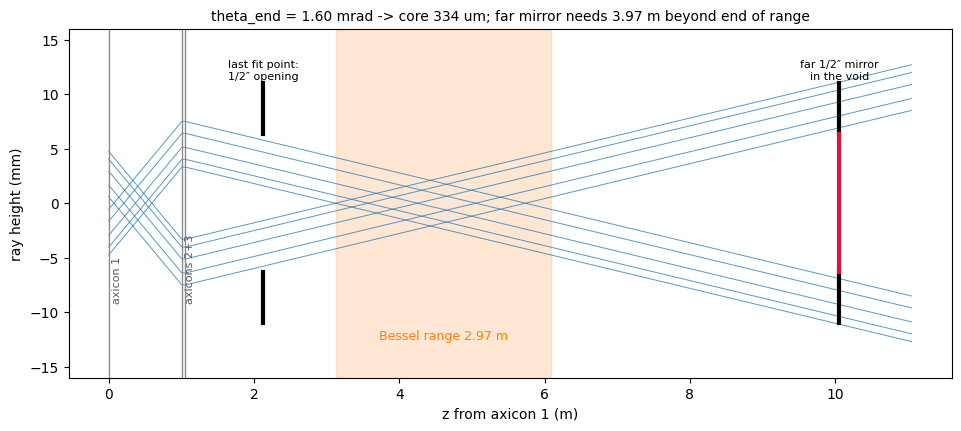

In [5]:
# --- meridional ray diagram of the current design ------------------------------
h0 = encircled_h(RAY_BAND[1]) * np.array([0.12, 0.35, 0.62, 0.85, 1.0])
res_f = analyze(verbose=False)
z_far = res_f['z_end'] + res_f['standoff']
z_axi = np.array([0.0, L12, L12 + L23])
z_pts = np.concatenate([z_axi, z_axi[-1] + np.linspace(1e-3, res_f['z_end'] + 1.25 * res_f['standoff'], 240)])

fig, ax = plt.subplots(figsize=(9.5, 4.2), constrained_layout=True)
for hh in h0:
    for sgn in (+1, -1):
        h_i, u_i, pts = sgn * hh, 0.0, []
        for k, (L, b, s) in enumerate(zip((0.0, L12, L23),
                                          deflect(np.deg2rad(ALPHA_DEG)), SIGNS)):
            h_i = h_i + u_i * L
            pts.append((z_axi[k], h_i))
            u_i = u_i - s * b * (1.0 if h_i >= 0 else -1.0)
        zt = z_pts[len(z_axi):]
        ax.plot([p[0] for p in pts] + list(zt),
                [p[1] / MM for p in pts] + list((h_i + u_i * (zt - z_axi[-1])) / MM),
                color="tab:blue", lw=0.7, alpha=0.75)
zs, ze = z_axi[-1] + res_f['z_start'], z_axi[-1] + res_f['z_end']
ax.axvspan(zs, ze, color="tab:orange", alpha=0.18)
for z, lab, dy in zip(z_axi, ("axicon 1", "axicons 2+3", ""), (9.2, 9.2, 0)):
    ax.axvline(z, color="0.55", lw=1)
    if lab:
        ax.annotate(lab, (z + 0.04, -dy), fontsize=8, ha="left", color="0.35",
                    rotation=90, va="bottom")
z_open = zs - (res_f['z_start'] - res_f['fit_from'])
for zm, filled in ((z_open, False), (z_axi[-1] + z_far, True)):
    ax.plot([zm, zm], [R_MIRROR / MM, 11], color="k", lw=3)
    ax.plot([zm, zm], [-R_MIRROR / MM, -11], color="k", lw=3)
    if filled:
        ax.plot([zm, zm], [-R_MIRROR / MM, R_MIRROR / MM], color="crimson", lw=3)
ax.annotate("last fit point:\n1/2\u2033 opening", (z_open, 11.4), fontsize=8,
            ha="center")
ax.annotate("far 1/2\u2033 mirror\nin the void", (z_axi[-1] + z_far, 11.4),
            fontsize=8, ha="center")
ax.annotate(f"Bessel range {res_f['window_len']:.2f} m", (0.5 * (zs + ze), -12.5),
            fontsize=9, ha="center", color="tab:orange")
ax.set_xlabel("z from axicon 1 (m)")
ax.set_ylabel("ray height (mm)")
ax.set_ylim(-16, 16)
ax.set_title(f"theta_end = {res_f['th_end']/MRAD:.2f} mrad -> core "
             f"{core_diam(res_f['th_end'])/UM:.0f} um; far mirror needs "
             f"{res_f['standoff']:.2f} m beyond end of range", fontsize=10)
save_fig("ray_diagram_current_design")
plt.show()

saved images/three_axicon_feasibility_calculator_2026_07_25/standoff_vs_core.png


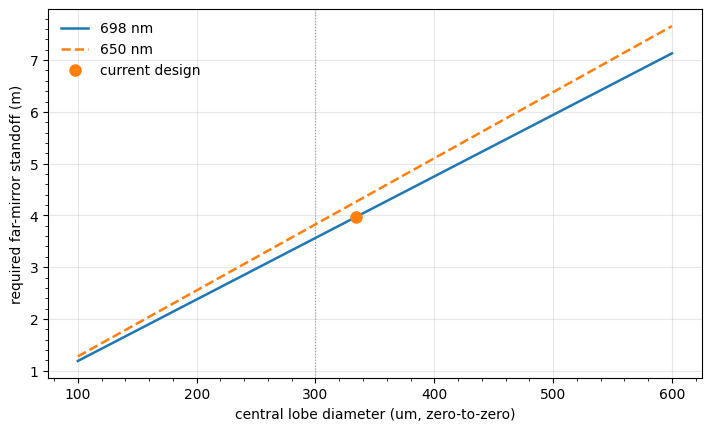

In [6]:
# --- the binding tradeoff: standoff vs core size -------------------------------
d_ax = np.linspace(100, 600, 300) * UM
fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
for lam, ls in ((698e-9, "-"), (650e-9, "--")):
    th = theta_cap(lam=lam, d_core=d_ax)
    ax.plot(d_ax / UM, VOID_MARGIN * R_MIRROR / th, ls, lw=1.8,
            label=f"{lam*1e9:.0f} nm")
ax.axvline(D_CORE / UM, color="0.6", lw=0.8, ls=":")
ax.plot(core_diam(res['th_end']) / UM, res['standoff'], "o", ms=8,
        color="tab:orange", label="current design")
ax.set_xlabel("central lobe diameter (um, "
              + ("zero-to-zero" if CORE_DEF == "zero" else "FWHM") + ")")
ax.set_ylabel("required far-mirror standoff (m)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.minorticks_on()
save_fig("standoff_vs_core")
plt.show()

### Prescribe a design

Inverse direction: pick the final cone angle (default: at the cap, with a margin
factor) and the annulus outer radius, get the bench prescription back. Cone-angle
reality check: the net mrad-scale convergence must be built from ~8 mrad-scale
deflections, so α₃ comes out well below the 0.5° stock floor — custom shallow
axicon, or pairing matched beyond the typical ±0.02–0.05° tolerance.

In [7]:
def prescribe(theta=None, margin=0.9, rho_out=8 * MM, alpha12_deg=1.0):
    """Matched-pair relay + shallow third axicon hitting cone angle theta
    (default margin*theta_cap) with annulus outer radius rho_out at axicon 3."""
    th = theta if theta is not None else margin * theta_cap()
    b12 = deflect(np.deg2rad(alpha12_deg))
    a3 = brentq(lambda a: deflect(a) - th, 1e-6, 0.2)      # exact inverse
    L12_p = rho_out / b12
    z_s, z_e = (rho_out - W_IN) / th, rho_out / th
    print(f"alpha1 = alpha2 = {alpha12_deg:.3f} deg (beta = {b12/MRAD:.3f} mrad), "
          f"SIGNS [+1,+1,+1]")
    print(f"L12 = {L12_p/MM:.0f} mm  -> annulus {rho_out/MM:.2f} mm outer, "
          f"{W_IN/MM:.2f} mm wide (L23 free, keep short)")
    print(f"alpha3 = {np.degrees(a3):.3f} deg -> theta = {th/MRAD:.3f} mrad, "
          f"core = {core_diam(th)/UM:.0f} um")
    print(f"range {z_s:.2f} - {z_e:.2f} m after axicon 3 ({W_IN/th:.2f} m); "
          f"1/2-inch opening fits from {(R_MIRROR - W_IN)/th:.2f} m below range start")
    print(f"far mirror clears (x{VOID_MARGIN:.0f}) at "
          f">= {VOID_MARGIN*R_MIRROR/th:.2f} m beyond end of range")

prescribe()

alpha1 = alpha2 = 1.000 deg (beta = 8.004 mrad), SIGNS [+1,+1,+1]
L12 = 1000 mm  -> annulus 8.00 mm outer, 4.75 mm wide (L23 free, keep short)
alpha3 = 0.200 deg -> theta = 1.603 mrad, core = 333 um
range 2.03 - 4.99 m after axicon 3 (2.96 m); 1/2-inch opening fits from 1.00 m below range start
far mirror clears (x1) at >= 3.96 m beyond end of range


### Sweep verification

Random configurations over the full Candidate-#1 sweep space (cone angles
0.05–5° each, both orientations, L₁₂ ≤ 2 m, L₂₃ ≤ 0.5 m) at fixed D = 9.5 mm.
Every config that passes constraints 1–3 is asked what standoff it needs — the
minimum should pin to the analytic floor. (The 2026-07-25 200 k-config run gave
3.565 m = floor to three decimals; default here is 30 k for runtime.)

In [8]:
N_CONFIGS = 30_000
rng = np.random.default_rng(7)
th_cap_v = theta_cap()

def eval_config(alphas_rad, signs, l12, l23, n=120):
    h = np.linspace(1e-5, 1.3 * W_IN, n)
    u = np.zeros_like(h)
    for L, b, s in zip((0.0, l12, l23), deflect(alphas_rad), signs):
        h = h + u * L
        u = u - s * b * np.where(h == 0, 1.0, np.sign(h))
    u = np.where(h < 0, -u, u)
    h = np.abs(h)
    if not np.all(u < 0):
        return None
    zc, th = -h / u, -u
    o = np.argsort(zc)
    zc, th = zc[o], th[o]
    ok = th <= th_cap_v
    best, i = 0.0, 0
    while i < len(zc):                       # longest window meeting the core cap
        if ok[i]:
            j = i
            while j + 1 < len(zc) and ok[j + 1]:
                j += 1
            best = max(best, zc[j] - zc[i])
            i = j + 1
        else:
            i += 1
    if best < L_RANGE or (h.max() - h.min()) > R_MIRROR:
        return None
    return R_MIRROR / th[-1]                 # standoff this config needs (margin x1)

needs = []
for _ in range(N_CONFIGS):
    a = np.deg2rad(rng.uniform([0.05] * 3, [5.0] * 3))
    s = rng.choice([-1, 1], 3)
    s[0] = 1
    r = eval_config(a, s, rng.uniform(0.05, 2.0), rng.uniform(0.005, 0.5))
    if r is not None:
        needs.append(r)
print(f"{len(needs)} / {N_CONFIGS} configs pass constraints 1-3")
print(f"min required standoff found = {min(needs):.3f} m   "
      f"(analytic floor R_mirror/theta_cap = {R_MIRROR/th_cap_v:.3f} m)")

385 / 30000 configs pass constraints 1-3
min required standoff found = 3.569 m   (analytic floor R_mirror/theta_cap = 3.565 m)


### Reading the calculator

Constraints 1–3 are open territory at D = 9.5 mm — the range comes out ≥ 2.7 m
automatically once the core is legal (with the side effect that the power is
diluted ~2.7× over the 1 m actually needed). Constraint 4 is not a design
variable: **the chamber must provide ≥ 3.6 m (698 nm, ×1 margin) between the top
ensemble and the far mirror**, ~3.8 m at 650 nm, double for the "≫" reading, and
double again if the 300 µm is meant as FWHM. The pending apparatus number is that
end-of-range → far-mirror distance; until it exists, Candidate #1 is *conditionally*
feasible. Levers if the chamber says no: smaller far mirror (¼″ → 1.8 m), holed /
annular far mirror, folding the exit path, or relaxing the core spec (breaks the
300 µm lattice-waist match).

Caveats vs wave optics: the geometric void edge is optimistic — diffraction
softens the annulus inner edge and the side-lobe pedestal carries light inside the
geometric shadow (quantify with the QDHT pipeline in `three_axicon_d9p5_2026_07_25`
before trusting a marginal clearance). The geometric "range" is the support of the
cone-crossing region; the QDHT on-axis window within it is shaped and narrower.